In [11]:
import sys, os
sys.path.append('../')
os.environ["JAX_PLATFORMS"] = "cpu"

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from corr_coeff_functions import build_corr_coeff_2D, build_rankdata_2D
from geometry import L2_distance, pairwise_similarities

from utils_double_well import generate_anchor_data, find_global_minimum_double_well

master_key = jax.random.PRNGKey(12345)
Ns = 500
noise_variance = 0.05
theta_deg = 35.0
translation = (1.2, -0.8)

A, A_prime = generate_anchor_data(
    master_key=master_key,
    Ns=Ns,
    noise_variance=noise_variance,
    theta_deg=theta_deg,
    translation=translation,
)

rankdata_2D = build_rankdata_2D()
xi_point_fn = build_corr_coeff_2D(average=False)

A.shape, A_prime.shape


((500, 2), (500, 2))

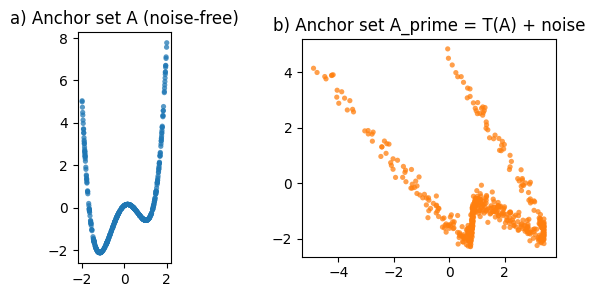

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0), gridspec_kw={'wspace': 0.2})

axes[0].scatter(np.array(A[:, 0]), np.array(A[:, 1]), s=14, c='tab:blue', alpha=0.75, edgecolors='none')
axes[0].set_title('a) Anchor set A (noise-free)')
axes[0].set_aspect('equal', adjustable='box')

axes[1].scatter(np.array(A_prime[:, 0]), np.array(A_prime[:, 1]), s=14, c='tab:orange', alpha=0.75, edgecolors='none')
axes[1].set_title('b) Anchor set A_prime = T(A) + noise')
axes[1].set_aspect('equal', adjustable='box')

plt.show()


In [13]:
# Global minimum G in the original space (independent from sampled anchors).
G = find_global_minimum_double_well()[None, :]

# Distances from G to original anchors, then ranks (no LOO).
dist_G_all = pairwise_similarities(L2_distance, G, A)[0]
ranks_G = rankdata_2D(dist_G_all[None, :])[0]

# Direct objective: maximize xi(|G-A|, |G_prime-A_prime|) in continuous 2D.
def xi_objective(g_prime):
    dist_Gprime_all = pairwise_similarities(L2_distance, g_prime[None, :], A_prime)[0]
    ranks_Gprime = rankdata_2D(dist_Gprime_all[None, :])[0]
    xi_forward, _ = xi_point_fn((ranks_G[None, :], ranks_Gprime[None, :]))
    return float(np.array(xi_forward)[0])

g_prime = np.array(jnp.mean(A_prime, axis=0))
learning_rate = 0.5
fd_eps = 1e-2
num_steps = 80
xi_obj_history = []

bounds_min = np.array(np.min(np.array(A_prime), axis=0) - 0.5)
bounds_max = np.array(np.max(np.array(A_prime), axis=0) + 0.5)

for _ in range(num_steps):
    f0 = xi_objective(jnp.array(g_prime))
    grad = np.zeros(2)
    for d in range(2):
        step_vec = np.zeros(2)
        step_vec[d] = fd_eps
        f_plus = xi_objective(jnp.array(g_prime + step_vec))
        f_minus = xi_objective(jnp.array(g_prime - step_vec))
        grad[d] = (f_plus - f_minus) / (2.0 * fd_eps)
    g_prime = g_prime + learning_rate * grad
    g_prime = np.clip(g_prime, bounds_min, bounds_max)
    xi_obj_history.append(f0)

G_prime_hat = jnp.array(g_prime)

# Directional xi at optimized G_prime (no LOO).
dist_Gprime_all = pairwise_similarities(L2_distance, G_prime_hat[None, :], A_prime)[0]
ranks_Gprime = rankdata_2D(dist_Gprime_all[None, :])[0]
xi_GGprime_vec, xi_GprimeG_vec = xi_point_fn((ranks_G[None, :], ranks_Gprime[None, :]))
xi_GGprime = float(np.array(xi_GGprime_vec)[0])
xi_GprimeG = float(np.array(xi_GprimeG_vec)[0])

min_dist_G_to_anchor = float(np.min(np.linalg.norm(np.array(A) - np.array(G[0])[None, :], axis=1)))

print(f'G (global minimum of the function) = {np.array(G[0])}')
print(f'min distance from G to sampled anchors = {min_dist_G_to_anchor:.6f}')
print(f'variational G_prime_hat = {np.array(G_prime_hat)}')
print(f'final xi objective = {xi_obj_history[-1]:.6f}')
print(f'xi(G, G_prime_hat) = {xi_GGprime:.6f}')
print(f'xi(G_prime_hat, G) = {xi_GprimeG:.6f}')

np.array(G_prime_hat), xi_GGprime, xi_GprimeG


G (global minimum of the function) = [-1.16214607 -2.13082686]
min distance from G to sampled anchors = 0.001587
variational G_prime_hat = [ 1.63895236 -0.75413653]
final xi objective = 0.744999
xi(G, G_prime_hat) = 0.745815
xi(G_prime_hat, G) = 0.453470


(array([ 1.63895236, -0.75413653]), 0.745814983259933, 0.45346981387925556)

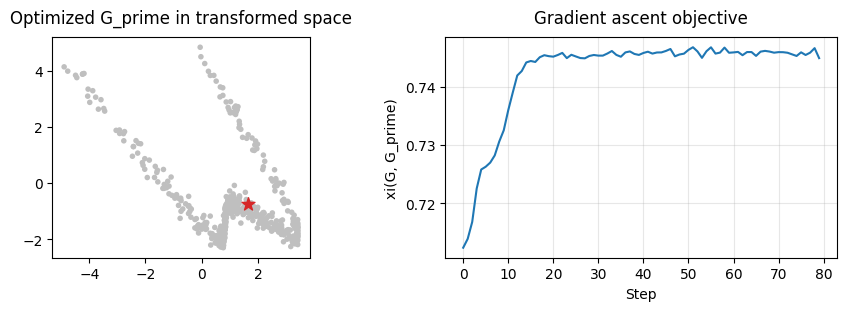

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.0), constrained_layout=True)

axes[0].scatter(np.array(A_prime[:, 0]), np.array(A_prime[:, 1]), c='0.75', s=16, edgecolors='none')
axes[0].scatter(float(G_prime_hat[0]), float(G_prime_hat[1]), c='tab:red', s=95, marker='*', zorder=3)
axes[0].set_title('Optimized G_prime in transformed space', pad=10)
axes[0].set_aspect('equal', adjustable='box')

axes[1].plot(xi_obj_history, color='tab:blue')
axes[1].set_title('Gradient ascent objective', pad=10)
axes[1].set_xlabel('Step')
axes[1].set_ylabel('xi(G, G_prime)')
axes[1].grid(True, alpha=0.3)

plt.show()


In [15]:
# LOO toy example removed: no LOO distances are needed for G / G_prime optimization.
